#Sentiment Analysis using Twitter Data
##Objective

Build a machine learning model that classifies tweets into:

Positive Sentiment

Neutral Sentiment

Negative Sentiment

using NLP techniques and machine learning algorithms

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("Twitter_Data.csv.zip")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


#Lets go with Data Preprocessing
let us check for the duplicate or null values and replace them with someother or remove the rows .. this can be done when we know and understand about the dataset

In [5]:
df.shape

(162980, 2)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


In [7]:
df.isnull().sum()

,0
clean_text,4
category,7


In [8]:
df.dropna(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

,0
clean_text,0
category,0


#SENTIMENT DISTRIBUTION
let us look for the situations which are more like positive, negative, neutral

In [11]:
df['category'].value_counts()

,count
category,
1.0,72249
0.0,55211
-1.0,35509


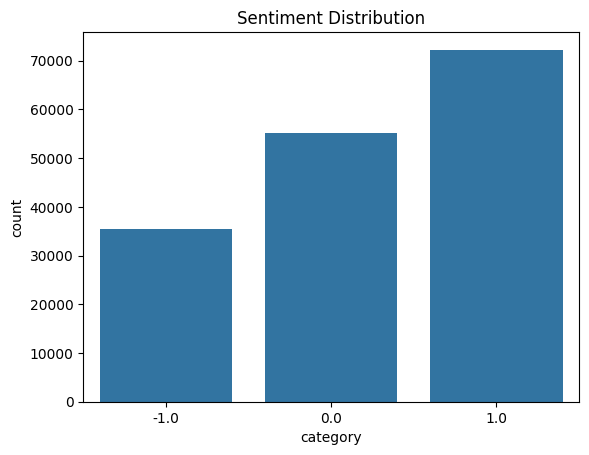

In [12]:
sns.countplot(x='category', data=df)
plt.title("Sentiment Distribution")
plt.show()

#TEXT VECTORIZATION
## Text Feature Extraction

TF-IDF Vectorization was applied to convert textual data into numerical features suitable for machine learning algorithms.

In [13]:
X = df['clean_text']
y = df['category']

tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

X = tfidf.fit_transform(X)

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

#NAIVE BAYES MODEL BUILDING

In [15]:
model = MultinomialNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7047309320733878


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        -1.0       0.86      0.43      0.58      7152
         0.0       0.79      0.64      0.70     11067
         1.0       0.64      0.89      0.75     14375

    accuracy                           0.70     32594
   macro avg       0.76      0.65      0.67     32594
weighted avg       0.74      0.70      0.69     32594



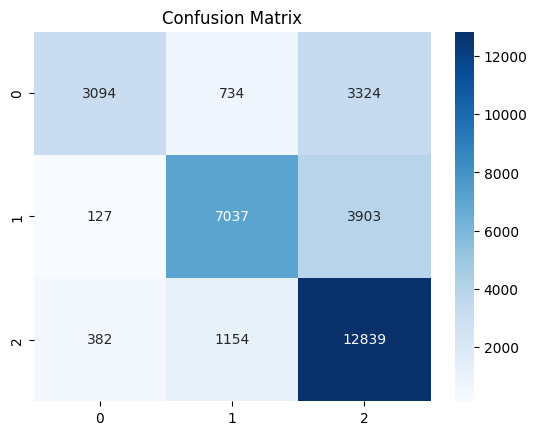

In [18]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("Confusion Matrix")
plt.show()

In [21]:
# User Input Prediction

user_text = input("Enter a tweet or sentence: ")

user_vector = tfidf.transform([user_text])

prediction = model.predict(user_vector)[0]

if prediction == 1:
    print("😊 Positive Sentiment")
elif prediction == 0:
    print("😐 Neutral Sentiment")
else:
    print("😞 Negative Sentiment")

Enter a tweet or sentence: the service is good
😊 Positive Sentiment


## Key Insights

- Sentiment analysis successfully categorized tweets into positive, neutral, and negative classes.
- TF-IDF effectively transformed text into numerical representations.
- Naive Bayes provided efficient baseline sentiment classification.
- The model can be applied to customer feedback, product reviews, and social media monitoring.